# Recrutement et transition écologique en France (2023)

## Contexte
La transition écologique implique une transformation profonde du marché du travail. 
Ce notebook analyse les données de l'enquête Besoins en Main d'Oeuvre (BMO) 2023 
de France Travail pour mesurer le poids des métiers verts et verdissants dans les
recrutements et identifier les tensions sur ces segments du marché du travail.

## Source des données
- Enquête BMO 2023 — France Travail / DARES  
Disponible sur : https://www.data.gouv.fr/datasets/enquete-besoins-en-main-doeuvre-bmo
- Classification des métiers verts et verdissants — Ministère de l'Écologie (ONEMEV)
- Table de correspondance FAP/ROME — DARES
  https://dares.travail-emploi.gouv.fr/donnees/la-nomenclature-des-familles-professionnelles-2009

## Structure de l'analyse
1. Chargement et nettoyage des données
2. Identification des métiers verts et verdissants
3. Poids des métiers verts et verdissants dans les recrutements
4. Volume de recrutement et tensions par métier
5. Comparaison verts / verdissants / autres
6. Disparités régionales
7. Métiers les plus en tension

## 1. Chargement, nettoyage et exploration des données
Chargement du fichier BMO 2023 et conversion des variables numériques. 
Les valeurs non numériques (ex: * pour données masquées) sont converties en NaN.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importation données DARES
chemin = r"C:\Users\Clément FAYS\OneDrive - Agence universitaire de la Francophonie\Bureau\Divers\Python\Formation\BMO\Donnees_consolidees_2023\Base_open_data_23.xlsx"

xl = pd.ExcelFile(chemin)
print("Onglets disponibles :", xl.sheet_names)

Onglets disponibles : ['Description des variables', 'BMO_2023_open_data']


In [3]:

df = pd.read_excel(chemin, sheet_name="BMO_2023_open_data")

# Premier aperçu
print(f"Dimensions : {df.shape}")
print("\nColonnes :")
print(df.columns.tolist())
df.head(10)

Dimensions : (50437, 14)

Colonnes :
['annee', 'Code métier BMO', 'Nom métier BMO', 'Famille_met', 'Lbl_fam_met', 'BE23', 'NOMBE23', 'Dept', 'NomDept', 'REG', 'NOM_REG', 'met', 'xmet', 'smet']


,annee,Code métier BMO,Nom métier BMO,Famille_met,Lbl_fam_met,BE23,NOMBE23,Dept,NomDept,REG,NOM_REG,met,xmet,smet
0,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,101,BASSIN BASSE-TERRE,971,Guadeloupe,1,Guadeloupe,250,58,47
1,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,102,BASSIN GRANDE-TERRE,971,Guadeloupe,1,Guadeloupe,174,114,132
2,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,103,BASSIN MARIE-GALANTE,971,Guadeloupe,1,Guadeloupe,*,*,*
3,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,104,BASSIN ILES DU NORD,971,Guadeloupe,1,Guadeloupe,32,*,16
4,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,105,BASSIN CENTRE,971,Guadeloupe,1,Guadeloupe,65,50,*
5,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,201,MARTINIQUE CENTRE,972,Martinique,2,Martinique,253,145,72
6,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,202,MARTINIQUE NORD ATLANTIQUE,972,Martinique,2,Martinique,236,155,33
7,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,203,MARTINIQUE SUD,972,Martinique,2,Martinique,203,137,150
8,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,204,MARTINIQUE NORD CARAIBE,972,Martinique,2,Martinique,53,43,22
9,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,302,SAINT LAURENT DU MARONI,973,Guyane,3,Guyane,44,17,30


In [4]:
# Dimensions
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")

# Noms des colonnes
print("Colonnes disponible :")
for col in df.columns:
    print(f"  - {col}")

Dimensions : 50437 lignes x 14 colonnes
Colonnes disponible :
  - annee
  - Code métier BMO
  - Nom métier BMO
  - Famille_met
  - Lbl_fam_met
  - BE23
  - NOMBE23
  - Dept
  - NomDept
  - REG
  - NOM_REG
  - met
  - xmet
  - smet


In [77]:
# Aperçu des premières lignes
df.head(10)

,annee,Code métier BMO,Nom métier BMO,Famille_met,Lbl_fam_met,BE23,NOMBE23,Dept,NomDept,REG,NOM_REG,met,xmet,smet
0,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,101,BASSIN BASSE-TERRE,971,Guadeloupe,1,Guadeloupe,250,58,47
1,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,102,BASSIN GRANDE-TERRE,971,Guadeloupe,1,Guadeloupe,174,114,132
2,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,103,BASSIN MARIE-GALANTE,971,Guadeloupe,1,Guadeloupe,*,*,*
3,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,104,BASSIN ILES DU NORD,971,Guadeloupe,1,Guadeloupe,32,*,16
4,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,105,BASSIN CENTRE,971,Guadeloupe,1,Guadeloupe,65,50,*
5,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,201,MARTINIQUE CENTRE,972,Martinique,2,Martinique,253,145,72
6,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,202,MARTINIQUE NORD ATLANTIQUE,972,Martinique,2,Martinique,236,155,33
7,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,203,MARTINIQUE SUD,972,Martinique,2,Martinique,203,137,150
8,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,204,MARTINIQUE NORD CARAIBE,972,Martinique,2,Martinique,53,43,22
9,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,302,SAINT LAURENT DU MARONI,973,Guyane,3,Guyane,44,17,30


In [78]:
# Types de variables et valeurs manquantes
print("Types de variables :")
print(df.dtypes)
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Types de variables :
annee               int64
Code métier BMO    object
Nom métier BMO     object
Famille_met        object
Lbl_fam_met        object
BE23                int64
NOMBE23            object
Dept               object
NomDept            object
REG                 int64
NOM_REG            object
met                object
xmet               object
smet               object
dtype: object
Valeurs manquantes par colonne :
annee              0
Code métier BMO    0
Nom métier BMO     0
Famille_met        0
Lbl_fam_met        0
BE23               0
NOMBE23            0
Dept               0
NomDept            0
REG                0
NOM_REG            0
met                0
xmet               0
smet               0
dtype: int64


In [79]:
# Voir les valeurs uniques de la colonne métier 
print(df.columns.tolist())

# Combien de métiers distincts ?
print(f"\nNombre de lignes : {len(df)}")

# Aperçu des 20 premières valeurs de chaque colonne
df.head(20)

['annee', 'Code métier BMO', 'Nom métier BMO', 'Famille_met', 'Lbl_fam_met', 'BE23', 'NOMBE23', 'Dept', 'NomDept', 'REG', 'NOM_REG', 'met', 'xmet', 'smet']

Nombre de lignes : 50437


,annee,Code métier BMO,Nom métier BMO,Famille_met,Lbl_fam_met,BE23,NOMBE23,Dept,NomDept,REG,NOM_REG,met,xmet,smet
0,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,101,BASSIN BASSE-TERRE,971,Guadeloupe,1,Guadeloupe,250,58,47
1,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,102,BASSIN GRANDE-TERRE,971,Guadeloupe,1,Guadeloupe,174,114,132
2,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,103,BASSIN MARIE-GALANTE,971,Guadeloupe,1,Guadeloupe,*,*,*
3,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,104,BASSIN ILES DU NORD,971,Guadeloupe,1,Guadeloupe,32,*,16
4,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,105,BASSIN CENTRE,971,Guadeloupe,1,Guadeloupe,65,50,*
5,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,201,MARTINIQUE CENTRE,972,Martinique,2,Martinique,253,145,72
6,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,202,MARTINIQUE NORD ATLANTIQUE,972,Martinique,2,Martinique,236,155,33
7,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,203,MARTINIQUE SUD,972,Martinique,2,Martinique,203,137,150
8,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,204,MARTINIQUE NORD CARAIBE,972,Martinique,2,Martinique,53,43,22
9,2023,A0Z40,Agriculteurs salariés,Z,Autres métiers,302,SAINT LAURENT DU MARONI,973,Guyane,3,Guyane,44,17,30


In [84]:
# Liste de tous les métiers uniques
metiers = df["Nom métier BMO"].unique()


In [7]:
# Vérifier le contenu de la colonne Famille_met
print(df["Code métier BMO"].unique()[:20])
print(f"\nNombre de familles distinctes : {df['Code métier BMO'].nunique()}")

['A0Z40' 'A0Z41' 'A0Z42' 'A0Z43' 'A1Z40' 'A1Z41' 'A1Z42' 'A2Z70' 'A2Z90'
 'A3Z40' 'A3Z41' 'A3Z90' 'B0Z20' 'B0Z21' 'B1Z40' 'B2Z40' 'B2Z41' 'B2Z42'
 'B2Z43' 'B2Z44']

Nombre de familles distinctes : 199


## 2. Identification des métiers verts et verdissants
Afin d'identifier les métiers "verts", nous nous basons sur la classification établie par le ministère de l'écologie en 2022 dans ce document : https://www.ecologie.gouv.fr/sites/default/files/documents/Onemev_emploi_metiers.pdf 

Ce document identifie les métiers dits "verts" (métier dont la finalité et/ou les compétences mises en œuvre contribuent à mesurer, prévenir, maîtriser, corriger les impacts négatifs et les dommages sur l’environnement) et "verdissants" (métier dont la finalité n’est pas environnementale, mais qui intègre de nouvelles « briques de compétence » pour prendre en compte de façon significative et quantifiable la dimension environnementale dans le geste métier) en se basant sur la nomenclature du répertoire opérationnel des métiers et des emplois (ROME).
L'enquête BMO utilisant la nomenclature des familles professionnelles (FAP 2009), la correspondance entre les 2 a dû être réalisée grâce à la table de correspondance disponible ici : https://dares.travail-emploi.gouv.fr/donnees/la-nomenclature-des-familles-professionnelles-2009

Les familles professionnelles (FAP) vertes et verdissantes ont ainsi pû être identifiées. Les FAP étant plus larges que les codes ROME, certaines correspondaient à plusieurs ROME dont certaines "vertes", d'autres "verdissantes". Dans ces rares cas, il a été décidé de considérer la FAP comme "verte".

**48 FAP** utilisées dans les données BMO sont concernées par ces définitions

In [9]:
# Charger la liste officielle des FAP vertes/verdissantes

chemin_fap = r"C:\Users\Clément FAYS\OneDrive - Agence universitaire de la Francophonie\Bureau\Divers\Python\Formation\BMO\FAP_vertes_verdissantes.xlsx"
df_fap_verts = pd.read_excel(chemin_fap, sheet_name="FAP vertes verdissantes")

# Garder uniquement les colonnes utiles
df_fap_verts = df_fap_verts[["Code FAP détaillé", "Catégorie"]].rename(columns={
    "Code FAP détaillé": "Code métier BMO",
    "Catégorie": "categorie_vert"
})

# Vérification
print(f"FAP vertes/verdissantes chargées : {len(df_fap_verts)}")
print(df_fap_verts["categorie_vert"].value_counts())
df_fap_verts

FAP vertes/verdissantes chargées : 48
categorie_vert
VERDISSANT    41
VERT           7
Name: count, dtype: int64


,Code métier BMO,categorie_vert
0,A0Z42,VERT
1,A1Z41,VERT
2,A2Z70,VERDISSANT
3,A2Z90,VERDISSANT
4,B0Z21,VERDISSANT
5,B2Z40,VERDISSANT
6,B2Z43,VERDISSANT
7,B2Z44,VERDISSANT
8,B3Z20,VERDISSANT
9,B4Z41,VERDISSANT


In [12]:
# Nettoyer les espaces insécables
df["Code métier BMO"] = df["Code métier BMO"].str.replace("\xa0", " ").str.strip()

# Jointure avec la liste officielle
df = df.merge(df_fap_verts, on="Code métier BMO", how="left")

# Créer les flags distincts
df["metier_vert"] = (df["categorie_vert"] == "VERT").astype(int)
df["metier_verdissant"] = (df["categorie_vert"] == "VERDISSANT").astype(int)
df["metier_vert_ou_verdissant"] = df["metier_vert"] | df["metier_verdissant"]

# Vérification
print(f"FAP VERT présentes dans le BMO : {df[df['metier_vert']==1]['Code métier BMO'].nunique()}")
print(f"FAP VERDISSANT présentes dans le BMO : {df[df['metier_verdissant']==1]['Code métier BMO'].nunique()}")
print(f"\nLignes VERT : {df['metier_vert'].sum()}")
print(f"Lignes VERDISSANT : {df['metier_verdissant'].sum()}")
print(f"Lignes total vert+verdissant : {df['metier_vert_ou_verdissant'].sum()}")



FAP VERT présentes dans le BMO : 7
FAP VERDISSANT présentes dans le BMO : 40

Lignes VERT : 2115
Lignes VERDISSANT : 11447
Lignes total vert+verdissant : 13562


In [15]:
# Convertir met et xmet en numérique (les * et autres caractères deviennent NaN)
df["met"] = pd.to_numeric(df["met"], errors="coerce")
df["xmet"] = pd.to_numeric(df["xmet"], errors="coerce")
df["smet"] = pd.to_numeric(df["smet"], errors="coerce")

# Vérification
print(f"Type de 'met' : {df['met'].dtype}")
print(f"Valeurs manquantes dans 'met' : {df['met'].isna().sum()}")

Type de 'met' : float64
Valeurs manquantes dans 'met' : 9196


## 3. Poids des métiers verts et verdissants
Les métiers verts représentent **21,6% des projets de recrutement** en France 
en 2023, dont 99830 métiers verts (3,3%) et 552410 métiers verdissants (18,3%)

In [19]:
# Agréger au niveau national
total_recrutements = df["met"].sum()
recrutements_verts = df[df["metier_vert"] == 1]["met"].sum()
part_verts = (recrutements_verts / total_recrutements * 100).round(1)


recrutements_verdissant = df[df["metier_verdissant"] == 1]["met"].sum()
part_verdissant = (recrutements_verdissant / total_recrutements * 100).round(1)

recrutements_vert_verdissant = df[df["metier_vert_ou_verdissant"] == 1]["met"].sum()
part_vert_verdissant = (recrutements_vert_verdissant / total_recrutements * 100).round(1)


print(f"Total projets de recrutement (France) : {total_recrutements:,}")
print(f"Dont métiers verts : {recrutements_verts:,}")
print(f"Dont métiers verdissants : {recrutements_verdissant:,}")
print(f"Part des métiers verts : {part_verts}%")
print(f"Part des métiers verdissants : {part_verdissant}%")
print(f"Part des métiers verts ou verdissants : {part_vert_verdissant}%")


Total projets de recrutement (France) : 3,013,134.0
Dont métiers verts : 99,830.0
Dont métiers verdissants : 552,410.0
Part des métiers verts : 3.3%
Part des métiers verdissants : 18.3%
Part des métiers verts ou verdissants : 21.6%


## 4. Volume et tensions par métier vert
Analyse du volume de recrutement et du taux de difficulté pour chacune des 47 FAP vertes ou verdissantes.

In [28]:
# Agréger par métier pour chaque catégorie
def agreger_par_metier(categorie_flag):
    return df[df[categorie_flag] == 1].groupby("Nom métier BMO").agg(
        recrutements=("met", "sum"),
        recrutements_difficiles=("xmet", "sum")
    ).reset_index().assign(
        taux_difficulte=lambda x: (x["recrutements_difficiles"] / x["recrutements"] * 100).round(1),
        categorie=categorie_flag.replace("metier_", "").upper()
    )

df_verts_met = agreger_par_metier("metier_vert")
df_verdissants_met = agreger_par_metier("metier_verdissant")
df_tous_met = agreger_par_metier("metier_vert_ou_verdissant")

# Combiner
df_analyse2 = pd.concat([df_verts_met, df_verdissants_met]).sort_values("recrutements", ascending=False)

print(f"Métiers verts : {len(df_verts_met)}")
print(f"Métiers verdissants : {len(df_verdissants_met)}")
df_analyse2.head(10)


Métiers verts : 7
Métiers verdissants : 40


,Nom métier BMO,recrutements,recrutements_difficiles,taux_difficulte,categorie
31,Professionnels de l'animation socioculturelle,79656.0,46897.0,58.9,VERDISSANT
13,Conducteurs routiers,41076.0,28891.0,70.3,VERDISSANT
26,Ouvriers non qualifiés du second œuvre du bâti...,38587.0,25983.0,67.3,VERDISSANT
25,Ouvriers non qualifiés du gros œuvre du bâtiment,36317.0,25828.0,71.1,VERDISSANT
3,Jardiniers salariés,34637.0,17378.0,50.2,VERT
12,Conducteurs et livreurs sur courte distance,31543.0,15609.0,49.5,VERDISSANT
5,Techniciens et agents de maîtrise de la mainte...,29813.0,21318.0,71.5,VERT
22,Maçons,29304.0,22715.0,77.5,VERDISSANT
27,"Ouvriers non qualifiés métallerie, serrurerie,...",22064.0,15130.0,68.6,VERDISSANT
30,"Plombiers, chauffagistes",22049.0,17866.0,81.0,VERDISSANT


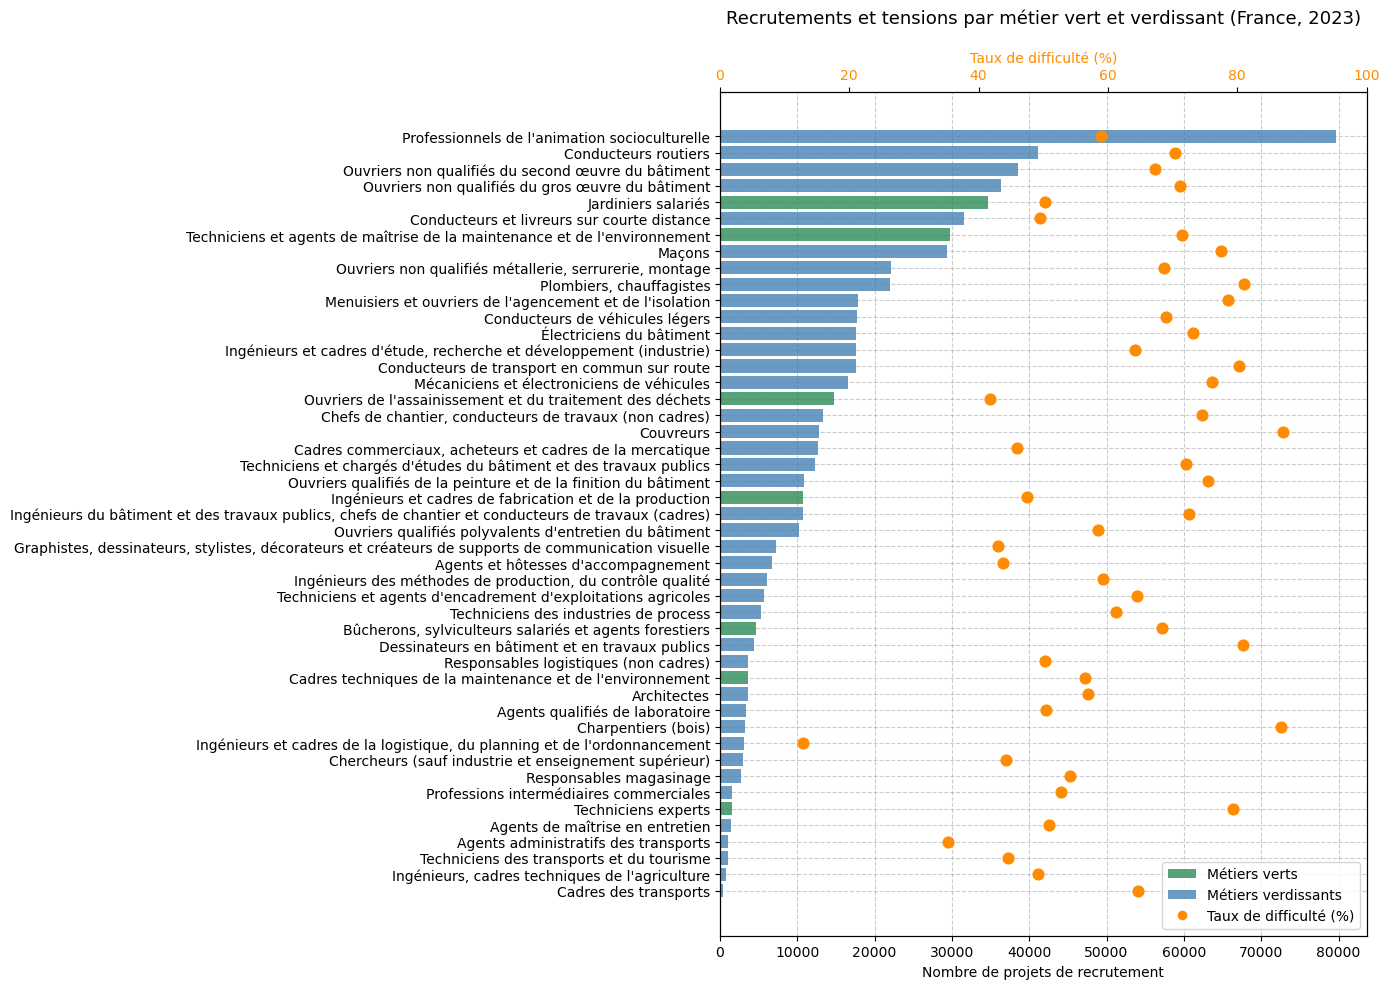

In [32]:
fig, ax1 = plt.subplots(figsize=(14, 10))

# Couleurs par catégorie
colors = df_analyse2["categorie"].map({"VERT": "seagreen", "VERDISSANT": "steelblue"})

ax1.barh(
    df_analyse2["Nom métier BMO"],
    df_analyse2["recrutements"],
    color=colors,
    alpha=0.8
)
ax1.set_xlabel("Nombre de projets de recrutement", color="black")
ax1.invert_yaxis()

ax2 = ax1.twiny()
ax2.scatter(
    df_analyse2["taux_difficulte"],
    df_analyse2["Nom métier BMO"],
    color="darkorange",
    zorder=5,
    s=60,
    label="Taux de difficulté (%)"
)
ax2.set_xlabel("Taux de difficulté (%)", color="darkorange")
ax2.tick_params(axis="x", labelcolor="darkorange")
ax2.set_xlim(0, 100)


# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="seagreen", alpha=0.8, label="Métiers verts"),
    Patch(facecolor="steelblue", alpha=0.8, label="Métiers verdissants"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=8, label="Taux de difficulté (%)"),
]
ax1.legend(handles=legend_elements, loc="lower right")

ax1.grid(axis="both", linestyle="--", alpha=0.4, color="gray")
ax1.set_axisbelow(True)

plt.title("Recrutements et tensions par métier vert et verdissant (France, 2023)", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

## 5. Comparaison verts / verdissants / autres
Contrairement aux métiers verts (56,5%), les métiers verdissants présentent
un taux de difficulté de recrutement significativement plus élevé (66,7%)
que la moyenne des autres métiers (59,5%). Ce résultat suggère que la
transformation écologique des métiers crée des tensions spécifiques sur
le marché du travail.

In [33]:
# Agréger par catégorie
comparaison = df.groupby("categorie_vert", dropna=False).agg(
    recrutements=("met", "sum"),
    recrutements_difficiles=("xmet", "sum")
).reset_index()

comparaison["categorie_vert"] = comparaison["categorie_vert"].fillna("Autres")
comparaison["taux_difficulte"] = (
    comparaison["recrutements_difficiles"] / comparaison["recrutements"] * 100
).round(1)

print(comparaison[["categorie_vert", "recrutements", "taux_difficulte"]])

  categorie_vert  recrutements  taux_difficulte
0     VERDISSANT      552410.0             66.7
1           VERT       99830.0             56.5
2         Autres     2360894.0             59.5


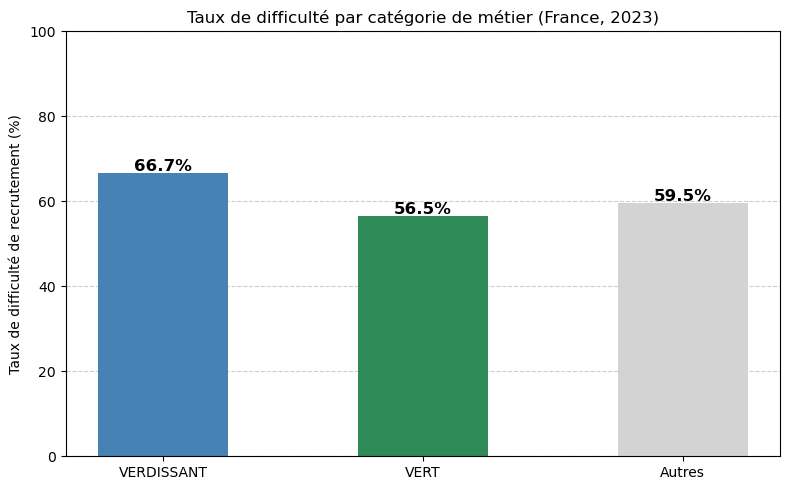

In [34]:
colors = {"VERT": "seagreen", "VERDISSANT": "steelblue", "Autres": "lightgray"}

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    comparaison["categorie_vert"],
    comparaison["taux_difficulte"],
    color=[colors[c] for c in comparaison["categorie_vert"]],
    width=0.5
)

for bar, val in zip(bars, comparaison["taux_difficulte"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val}%",
        ha="center", fontsize=12, fontweight="bold"
    )

ax.set_ylim(0, 100)
ax.set_ylabel("Taux de difficulté de recrutement (%)")
ax.set_title("Taux de difficulté par catégorie de métier (France, 2023)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4, color="gray")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Les métiers verdissants sont nettement plus en tension (66,7%) que la moyenne des autres métiers (59,5%) — +7 points d'écart**

Les métiers verts sont au contraire légèrement moins en tension (56,5%)

Les métiers en cours de transformation écologique — ceux qui nécessitent de nouvelles compétences environnementales sans en faire leur cœur — sont ceux qui peinent le plus à recruter.

## 6. Disparités régionales
Analyse des différences de difficulté à récruter pour les métiers verts et verdissants selon les régions.

In [73]:
## Création d'un tableau et calcul de l'indicateur de difficulté par région/catégorie de métier
# Agréger par région et catégorie
df_regions = df.groupby(
    ["NOM_REG", "categorie_vert"],dropna=False
).agg(
    recrutements=("met", "sum"),
    recrutements_difficiles=("xmet", "sum")
).reset_index()

df_regions["taux_difficulte"] = (
    df_regions["recrutements_difficiles"] / df_regions["recrutements"] * 100
).round(1)

# Renommer NaN en "Autres"
df_regions["categorie_vert"] = df_regions["categorie_vert"].fillna("Autres")

print(df_regions.head(10))

                   NOM_REG categorie_vert  recrutements  \
0     Auvergne-Rhône-Alpes     VERDISSANT       71621.0   
1     Auvergne-Rhône-Alpes           VERT       12259.0   
2     Auvergne-Rhône-Alpes         Autres      282851.0   
3  Bourgogne-Franche-Comté     VERDISSANT       17731.0   
4  Bourgogne-Franche-Comté           VERT        3366.0   
5  Bourgogne-Franche-Comté         Autres       84546.0   
6                 Bretagne     VERDISSANT       27831.0   
7                 Bretagne           VERT        4908.0   
8                 Bretagne         Autres      128545.0   
9      Centre-Val de Loire     VERDISSANT       20233.0   

   recrutements_difficiles  taux_difficulte  
0                  50523.0             70.5  
1                   7501.0             61.2  
2                 170531.0             60.3  
3                  10755.0             60.7  
4                   1829.0             54.3  
5                  45525.0             53.8  
6                  18651.0  

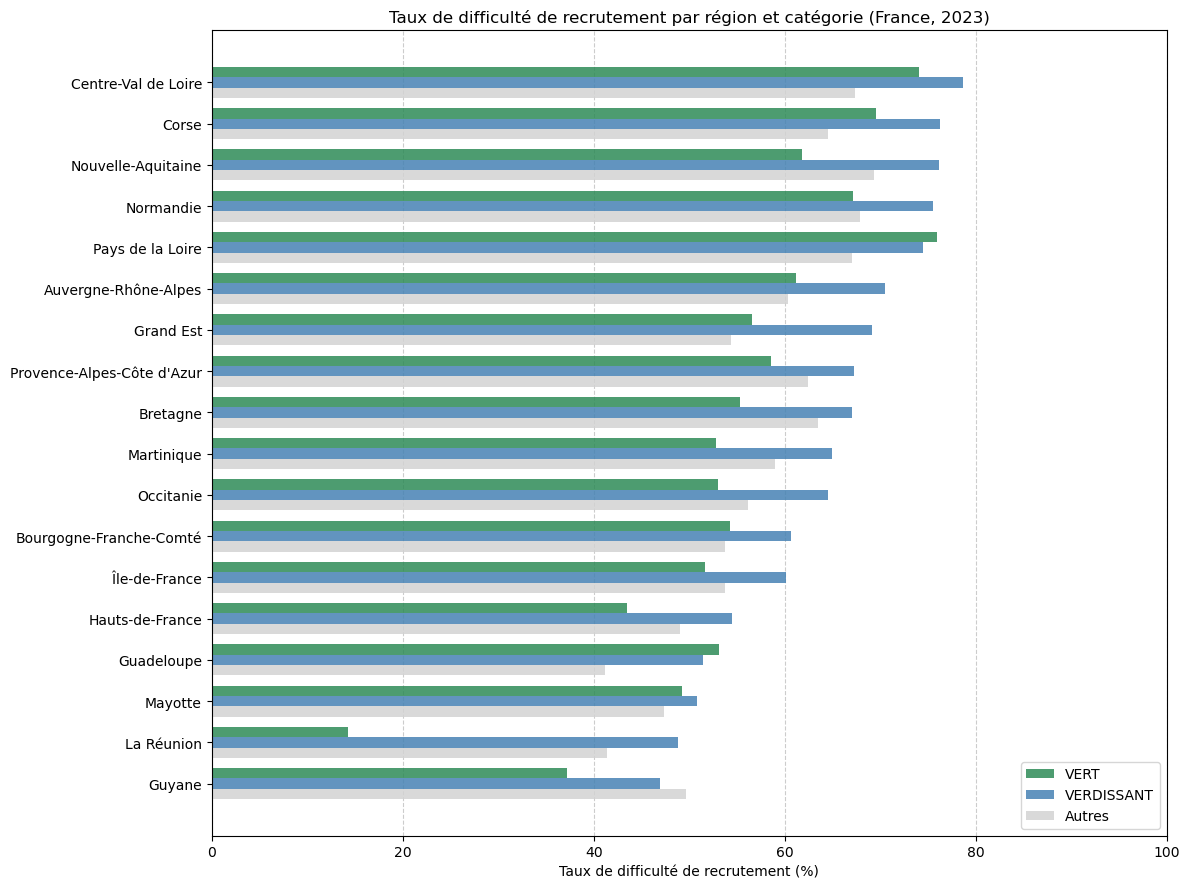

In [72]:
##Représentation graphique de l'indicateur de difficulté par région/catégorie de métier
import numpy as np

# Pivoter sur le taux de difficulté pour les 3 catégories
df_pivot_taux = df_regions.pivot(
    index="NOM_REG", columns="categorie_vert", values="taux_difficulte"
).fillna(0)

# Trier par taux de difficulté VERDISSANT décroissant
df_pivot_taux = df_pivot_taux.sort_values("VERDISSANT", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

y = np.arange(len(df_pivot_taux))
height = 0.25

ax.barh(y + height, df_pivot_taux["VERT"], height=height,
        color="seagreen", alpha=0.85, label="VERT")
ax.barh(y, df_pivot_taux["VERDISSANT"], height=height,
        color="steelblue", alpha=0.85, label="VERDISSANT")
ax.barh(y - height, df_pivot_taux["Autres"], height=height,
        color="lightgray", alpha=0.85, label="Autres")

ax.set_yticks(y)
ax.set_yticklabels(df_pivot_taux.index)
ax.set_xlabel("Taux de difficulté de recrutement (%)")
ax.set_xlim(0, 100)
ax.grid(axis="x", linestyle="--", alpha=0.4, color="gray")
ax.set_axisbelow(True)
ax.legend(loc="lower right")

plt.title("Taux de difficulté de recrutement par région et catégorie (France, 2023)", fontsize=12)
plt.tight_layout()
plt.show()

Un élément notable est l'apparente **relative facilité de recrutement dans les DROM** sur les métiers "verts" en comparaison des régions de France métropolitaine - bien que la signification statistique de ces écarts n'est pas vérifiée.

**La granularité de l'analyse est maintenant augmentée** - l'attention est portée sur les combinaisons région/métier afin d'identifier si certains métiers "verts" sont particulièrement en tension dans certains territoires

In [76]:
## Création d'un tableau et calcul de l'indicateur de difficulté par région/métier 

# Agréger par région, métier et catégorie
df_reg_met = df[df["metier_vert_ou_verdissant"] == 1].groupby(
    ["NOM_REG", "Nom métier BMO", "categorie_vert"]
).agg(
    recrutements=("met", "sum"),
    recrutements_difficiles=("xmet", "sum")
).reset_index()

df_reg_met["taux_difficulte"] = (
    df_reg_met["recrutements_difficiles"] / df_reg_met["recrutements"] * 100
).round(1)

# Top 20 des combinaisons les plus en tension
# avec seuil minimum de recrutements pour éviter les cas marginaux
top_tensions = df_reg_met[df_reg_met["recrutements"] >= 200]\
    .sort_values("taux_difficulte", ascending=False)\
    .head(20)

print(top_tensions[["NOM_REG", "Nom métier BMO", "categorie_vert", "recrutements", "taux_difficulte"]])

                     NOM_REG  \
686         Pays de la Loire   
592       Nouvelle-Aquitaine   
176      Centre-Val de Loire   
596       Nouvelle-Aquitaine   
82   Bourgogne-Franche-Comté   
545                Normandie   
103                 Bretagne   
589       Nouvelle-Aquitaine   
157      Centre-Val de Loire   
606       Nouvelle-Aquitaine   
110                 Bretagne   
246                Grand Est   
549                Normandie   
161      Centre-Val de Loire   
16      Auvergne-Rhône-Alpes   
35      Auvergne-Rhône-Alpes   
9       Auvergne-Rhône-Alpes   
150      Centre-Val de Loire   
169      Centre-Val de Loire   
579                Normandie   

                                        Nom métier BMO categorie_vert  \
686       Conducteurs de transport en commun sur route     VERDISSANT   
592       Conducteurs de transport en commun sur route     VERDISSANT   
176                           Plombiers, chauffagistes     VERDISSANT   
596                                

On note que **le top 20 ne contient que des métiers verdissants**, ce qui est consistant avec les conclusions de l'analyse précédente

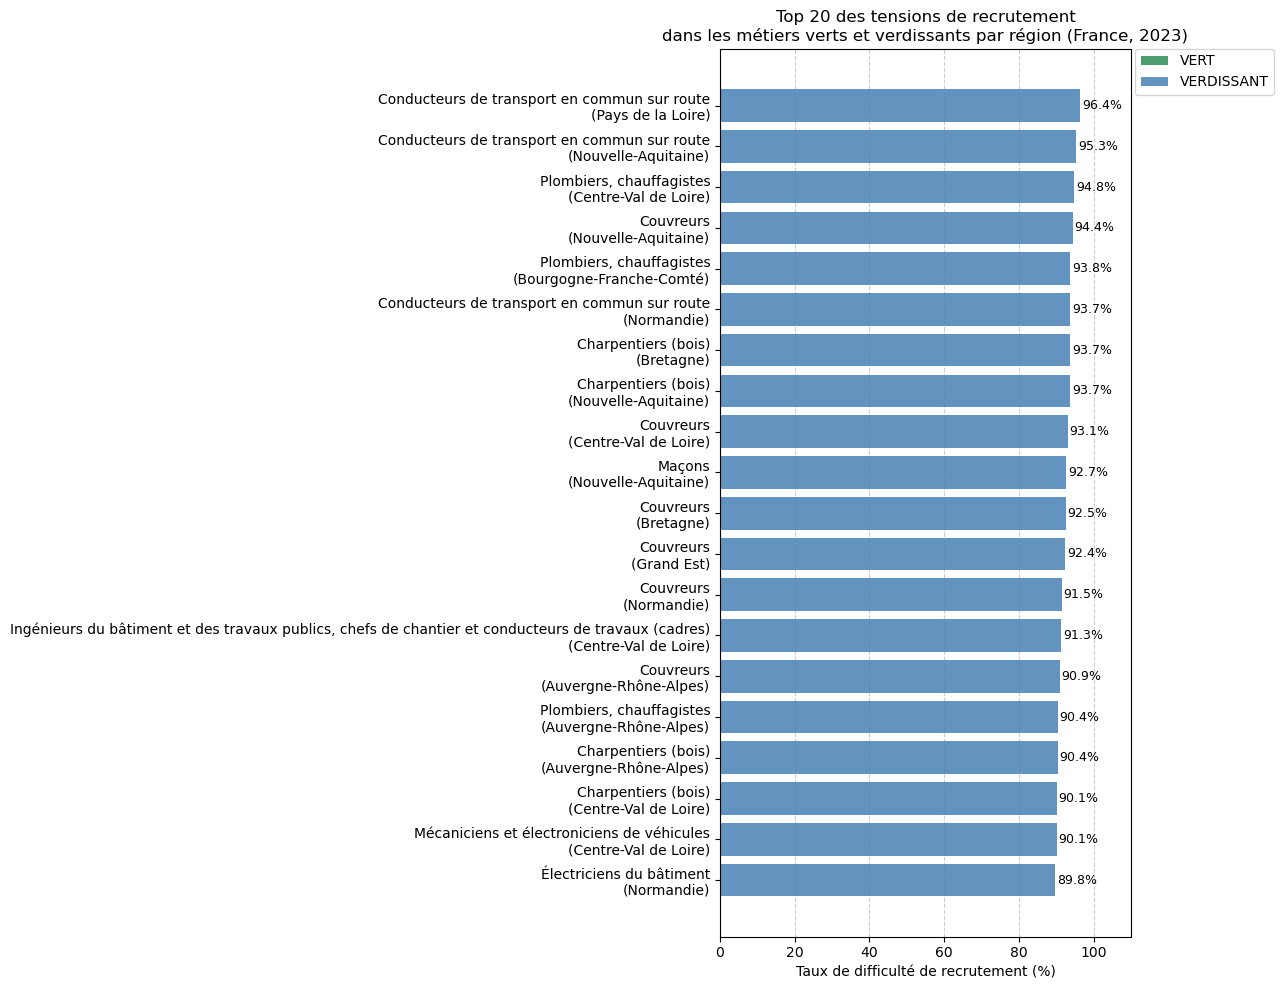

In [78]:
##Représentation graphique simple du top 20 des combinaison région/métier en tension

# Créer un label combiné région + métier
top_tensions["label"] = (
    top_tensions["Nom métier BMO"] + "\n(" + top_tensions["NOM_REG"] + ")"
)

colors = top_tensions["categorie_vert"].map({"VERT": "seagreen", "VERDISSANT": "steelblue"})

fig, ax = plt.subplots(figsize=(13, 10))

bars = ax.barh(
    top_tensions["label"],
    top_tensions["taux_difficulte"],
    color=colors,
    alpha=0.85
)

# Valeurs au bout des barres
for bar, val in zip(bars, top_tensions["taux_difficulte"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val}%",
        va="center", fontsize=9
    )

ax.set_xlim(0, 110)
ax.set_xlabel("Taux de difficulté de recrutement (%)")
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4, color="gray")
ax.set_axisbelow(True)

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="seagreen", alpha=0.85, label="VERT"),
    Patch(facecolor="steelblue", alpha=0.85, label="VERDISSANT"),
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)

plt.title("Top 20 des tensions de recrutement\ndans les métiers verts et verdissants par région (France, 2023)",
          fontsize=12)
plt.tight_layout()
plt.show()

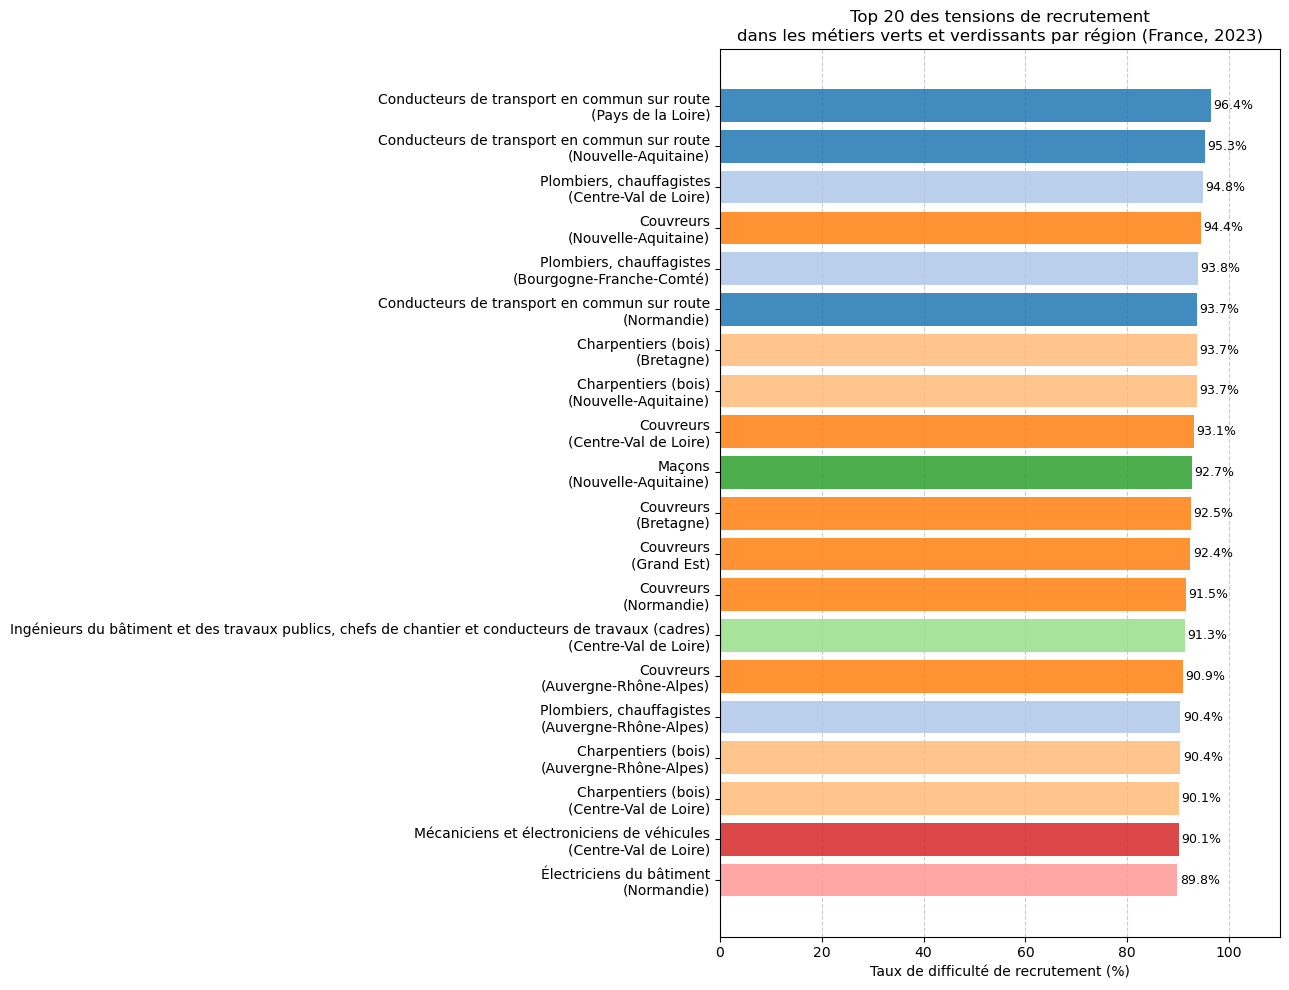

In [79]:
## Enrichissement du graphique précédent en idnetifiant les métiers avec une couleur commune

import matplotlib.cm as cm

# Créer une palette de couleurs par métier
metiers_uniques = top_tensions["Nom métier BMO"].unique()
palette = cm.tab20.colors  # 20 couleurs distinctes
couleurs_metiers = {metier: palette[i % 20] for i, metier in enumerate(metiers_uniques)}

colors = top_tensions["Nom métier BMO"].map(couleurs_metiers)

fig, ax = plt.subplots(figsize=(13, 10))

bars = ax.barh(
    top_tensions["label"],
    top_tensions["taux_difficulte"],
    color=colors,
    alpha=0.85
)

for bar, val in zip(bars, top_tensions["taux_difficulte"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val}%",
        va="center", fontsize=9
    )

ax.set_xlim(0, 110)
ax.set_xlabel("Taux de difficulté de recrutement (%)")
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4, color="gray")
ax.set_axisbelow(True)

# Légende par métier en dehors du graphique
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=couleurs_metiers[m], alpha=0.85, label=m)
    for m in metiers_uniques
]

plt.title("Top 20 des tensions de recrutement\ndans les métiers verts et verdissants par région (France, 2023)",
          fontsize=12)
plt.tight_layout()
plt.show()

**Ce graphique permet de constater facilement que certains métiers sont en grande tension de manière récurrente.** Il s'agit notamment des métiers de:
- Conducteurs de transports en commun sur route
- Plombiers, chauffagistes
- Couvreurs
- Charpentiers
  
Cette analyse est relativement consistante avec celle menée dans la section 4. Toutefois elle permet de mettre en lumière des différence régionale importante quant à la tension de recrutement sur certains métiers.

**Nous poursuivons ci-dessous l'analyse régionale en représentant visuellement les différence en difficulté à recruter sur les métiers "verts" selon les régions**

In [81]:
#importation des packages nécessaires
import geopandas as gpd
print(geopandas.__version__)

1.1.1


In [56]:
# Charger le contour des régions françaises
url_regions = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions-version-simplifiee.geojson"
gdf_regions = gpd.read_file(url_regions)

print(gdf_regions.columns.tolist())
print(gdf_regions.head())

C:\Users\Public\Python\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


['code', 'nom', 'geometry']
  code                      nom  \
0   11            Île-de-France   
1   24      Centre-Val de Loire   
2   27  Bourgogne-Franche-Comté   
3   28                Normandie   
4   32          Hauts-de-France   

                                            geometry  
0  POLYGON ((2.59052 49.07965, 2.63327 49.10838, ...  
1  POLYGON ((2.87463 47.52042, 2.88845 47.50943, ...  
2  POLYGON ((3.62942 46.74946, 3.57569 46.74952, ...  
3  POLYGON ((-1.11962 49.35557, -1.07822 49.38849...  
4  POLYGON ((4.04797 49.40564, 4.03991 49.3974, 4...  


In [57]:
# Comparer les noms de régions dans les deux sources afin de vérifier la compatibilité des 2 jeux de données
print("Régions dans le GeoJSON :")
print(sorted(gdf_regions["nom"].tolist()))

print("\nRégions dans le BMO :")
print(sorted(df["NOM_REG"].unique().tolist()))

Régions dans le GeoJSON :
['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire', 'Corse', 'Grand Est', 'Hauts-de-France', 'Normandie', 'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire', "Provence-Alpes-Côte d'Azur", 'Île-de-France']

Régions dans le BMO :
['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire', 'Corse', 'Grand Est', 'Guadeloupe', 'Guyane', 'Hauts-de-France', 'La Réunion', 'Martinique', 'Mayotte', 'Normandie', 'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire', "Provence-Alpes-Côte d'Azur", 'Île-de-France']


**Résultat :** les noms sont bien les mêmes mais le GeoJSON ne contient que la France métropolitaine. La représentation géographique ne se concentrera donc que sur le cas de la Métropole

C:\Users\Clément FAYS\AppData\Local\Temp\ipykernel_22484\4064507650.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])  # laisser de la place en bas pour la colorbar


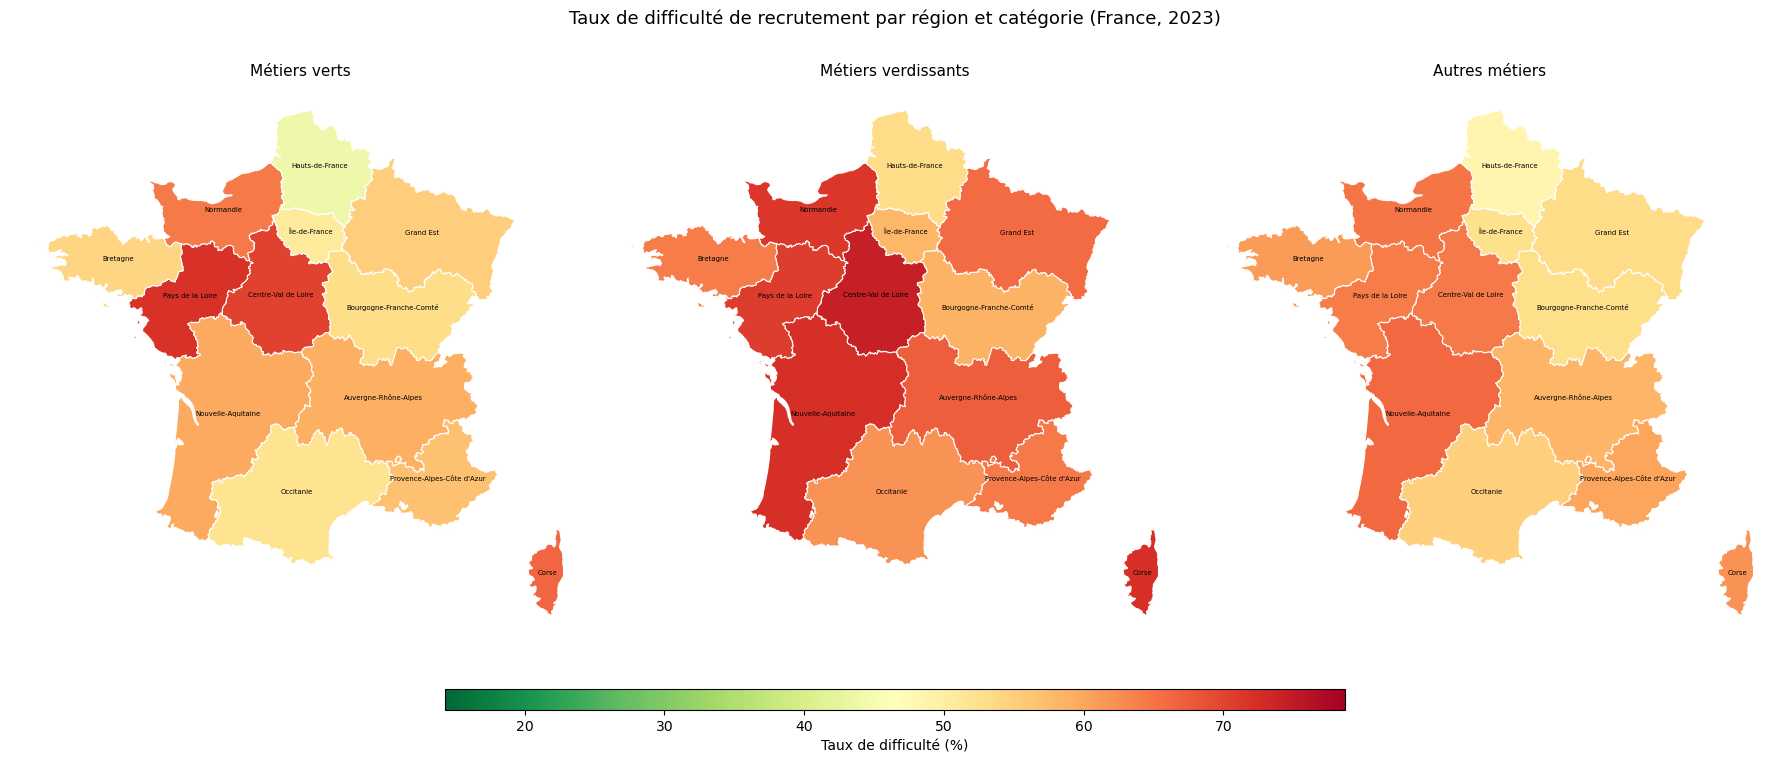

In [67]:
### Préparation de la base de données et réalisation de la carte choroplèthe

# Préparer les données : taux de difficulté des métiers verdissants par région
df_carte = df_regions[df_regions["categorie_vert"] == "VERDISSANT"][["NOM_REG", "taux_difficulte"]].copy()

# Jointure avec le GeoJSON
gdf_carte = gdf_regions.merge(df_carte, left_on="nom", right_on="NOM_REG", how="left")

# Carte choroplèthe
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

categories = ["VERT", "VERDISSANT", "Autres"]
titres = ["Métiers verts", "Métiers verdissants", "Autres métiers"]

vmin = df_regions["taux_difficulte"].min()
vmax = df_regions["taux_difficulte"].max()

for ax, categorie, titre in zip(axes, categories, titres):
    df_carte = df_regions[df_regions["categorie_vert"] == categorie][["NOM_REG", "taux_difficulte"]].copy()
    gdf_carte = gdf_regions.merge(df_carte, left_on="nom", right_on="NOM_REG", how="left")

    gdf_carte.plot(
        column="taux_difficulte",
        cmap="RdYlGn_r",
        linewidth=0.8,
        edgecolor="white",
        legend=False,
        vmin = df_regions["taux_difficulte"].min() - 5,
        vmax = df_regions["taux_difficulte"].max() + 5,
        ax=ax
    )

    for _, row in gdf_carte.iterrows():
        ax.annotate(
            text=row["nom"],
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            ha="center", fontsize=5, color="black"
        )

    ax.set_axis_off()
    ax.set_title(titre, fontsize=11)

# Colorbar dans un axe séparé en bas
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
sm = ScalarMappable(cmap="RdYlGn_r", norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

# Ajouter un axe dédié pour la colorbar
cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Taux de difficulté (%)", fontsize=10)

plt.suptitle("Taux de difficulté de recrutement par région et catégorie (France, 2023)",
             fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0.08, 1, 1])  # laisser de la place en bas pour la colorbar
plt.show()

**Les cartes permettent de se rendre compte que l'excédent de difficulté rencontré au recrutement des métiers verdissants est plutôt vérifié sur l'ensemble du territoire, mais est particulirement tiré vers le haut par les régions :**
- **Centre - Val de Loire**
- **Pays de la Loire**
- **Normandie**
- **Corse**
  
On constate par ailleurs que ces 4 régions se distinguent également pour leur difficulté à recruter sur la catégorie des métiers verts. Un effort particulier de formation et de promotion des métiers de la transition écologique pourrait donc nécessaire dans ces 4 régions.

## 7. Focus sur les métiers les plus en tension
Identification des métiers verts présentant les taux de difficulté 
les plus élevés (seuil minimum : 500 projets de recrutement).

In [85]:
# Top 10 des métiers les plus en tension par catégorie
# avec seuil minimum de recrutements
top_verts = df[df["metier_vert"] == 1].groupby("Nom métier BMO").agg(
    recrutements=("met", "sum"),
    recrutements_difficiles=("xmet", "sum")
).reset_index()
top_verts["taux_difficulte"] = (top_verts["recrutements_difficiles"] / top_verts["recrutements"] * 100).round(1)
top_verts = top_verts[top_verts["recrutements"] >= 500].sort_values("taux_difficulte", ascending=False).head(20)

top_verdissants = df[df["metier_verdissant"] == 1].groupby("Nom métier BMO").agg(
    recrutements=("met", "sum"),
    recrutements_difficiles=("xmet", "sum")
).reset_index()
top_verdissants["taux_difficulte"] = (top_verdissants["recrutements_difficiles"] / top_verdissants["recrutements"] * 100).round(1)
top_verdissants = top_verdissants[top_verdissants["recrutements"] >= 500].sort_values("taux_difficulte", ascending=False).head(20)


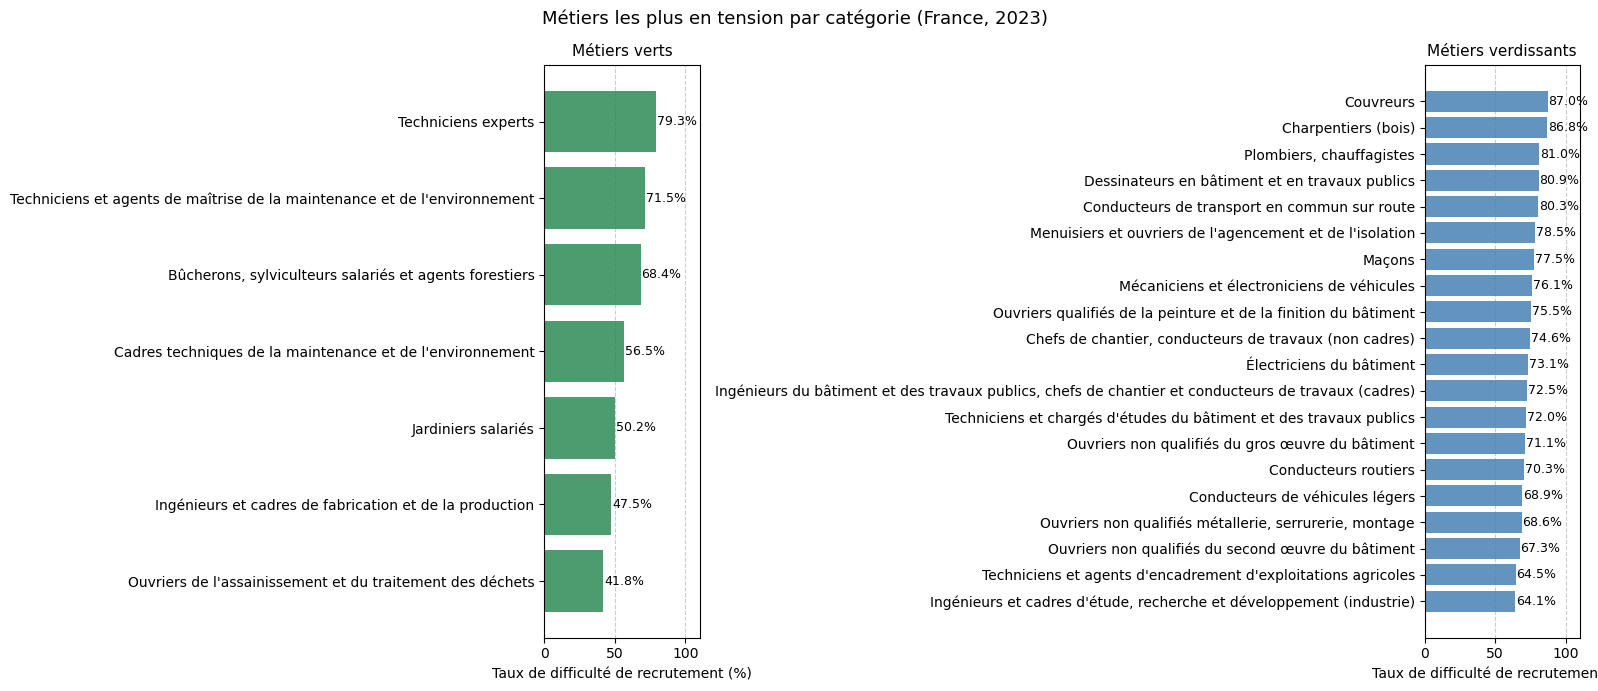

In [86]:
## Représentation graphique des taux de difficulté des métiers les plus en tension par catégorie

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, df_top, titre, color in zip(
    axes,
    [top_verts, top_verdissants],
    ["Métiers verts", "Métiers verdissants"],
    ["seagreen", "steelblue"]
):
    df_top_sorted = df_top.sort_values("taux_difficulte", ascending=True)
    
    bars = ax.barh(
        df_top_sorted["Nom métier BMO"],
        df_top_sorted["taux_difficulte"],
        color=color,
        alpha=0.85
    )

    for bar, val in zip(bars, df_top_sorted["taux_difficulte"]):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{val}%",
            va="center", fontsize=9
        )

    ax.set_xlim(0, 110)
    ax.set_xlabel("Taux de difficulté de recrutement (%)")
    ax.set_title(titre, fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.4, color="gray")
    ax.set_axisbelow(True)

plt.suptitle("Métiers les plus en tension par catégorie (France, 2023)", fontsize=13)
plt.tight_layout()
plt.show()

Ce visuel permet de valider l'observation que les métiers verts sont relativement peu tendus en comparaison des métiers verdissants. Il est toutefois intéressant de noter que **les métiers verts les plus tendus sont des métiers de techniciens très qualifiés**, un deficit de volume de formation sur ces métiers est donc à explorer.
En ce qui concerne les métiers verdissants, **on notera la surreprésentation des métiers du batiment dans le top 10 des métiers en tension aun niveau national**. Le secteur de la construction étant un pilier de la transition écologique, notamment à travers la rénovation des batiments, **il semble important de trouver des solutions pour accroitre l'attractivité des ces métiers.**

## Conclusions

L'analyse des données BMO 2023 permet de tirer trois enseignements principaux :

1. **Les métiers de la transition écologique représentent une part significative du marché du travail** 
Plus d'1 projet de recrutement sur 5 (21,6%) en 2023 concernait des métiers dits "verts" ou "verdissants". Cela met en lumière l'importance qu'ont aujourd'hui ces métiers pour l'économie française  

2. **Les tensions de recrutement sont hétérogènes mais ciblées** : 
Les métiers verdissants rencontrent des difficultés à recruter plus importantes que les métiers verts, ou que les autres métiers en général. Cela peut potentiellement s'expliquer en partie par le besoin pour la main d'oeuvre existante d'acquérir des compétences spécifiques à la transition écologique pour remplir ces emplois. Une autre explication probable réside dans le fait que les métiers verdissants en tension sont en grande partie des métiers en manque de reconnaissance - tels que dans la construction ou le transport de passagers sur route. Des politiques d'attractivité sur ces types d'emplois seraient donc nécessaires afin qu'ils puissent remplir leur rôle dans la transition écologique de la France.
On constate en parallèle des difficultés à recruter dans des métiers de techniciens qualifiés sur des thématiques explicitement vertes. Une étude dédiée aux raisons de ces difficultés pourrait être menée, mais une hypothèse est celle du manque de diplomés sur ces sujets - qui pourrait être résorbé via une augmentation de l'offre de formation


3. **Des disparités régionales existent** bien que relativement limitées
En particulier, les régions Centre, Pays de la Loire, Normandie et Corse semblent rencontrer de plus grandes difficultés à recruter dans les métiers de la transition écologique.
A l'autre bout du spectre, les DROM semblent rencontrer moins de difficulté de recrutement sur ces types d'emplois.

### Perspectives
L'étude des besoins de main d'oeuvre pour les métiers de la transition écologique est un champ d'analyse très large, et cette première exploration des données de l'enquête BMO de 2023 ouvre la porte à de nombreuses questions. Quelques exemples d'analyse complémentaires sont :
- Vérification de la signification statistiques des écarts de difficulté observés entre métiers et entre régions
- Analyse longitudinale de l'indicateur "taux de difficulté de recrutement" afin d'observer des tendances
- Analyse des causes profondes des difficulté de recrutement dans chaque secteur/région afin de proposer des solutions de politique publique pertinentes (mélange d'analyse qualitative et de modèles de régression pour identifier les variables explicatives de l'indicateur)

